notebook for testing functions as they migrate from notebook to src/

In [1]:
# imports
from src.data.loader import (
	load_dataset, 
	load_raw
)
from src.visualization.data_visualization import (
	plot_label_distribution,
	plot_correlation_heatmap,
	plot_correlated_pairs
)

from src.data.resampler import resample

from src.models.lgbm import (
    train_lightgbm_classifier,
    classification_report_for_model as lgbm_report,
    predict_labels as lgbm_predict_labels
)

from src.models.cnn import (
    train_cnn_classifier,
    classification_report_for_model as cnn_report,
    predict_labels
)

from src.models.mlp import (
    train_mlp_classifier,
    classification_report_for_model as mlp_report,
    predict_labels
)


In [2]:
# load data
df = load_dataset()
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Loading cleaned dataset from cache at cache/cleaned.parquet
Shape: (2522362, 62)
Columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 

In [3]:
# verify cleaning was applied
assert df.isnull().sum().sum() == 0, "Data contains missing values"
assert 'Label' in df.columns, "Label column is missing"
assert df.shape[1] == 62, f"Expected 62 columns after cleaning, got {df.shape[1]}"
print("Data loading and verification successful.")

Data loading and verification successful.


Loading raw dataset from Kaggle...
Raw shape: 2,830,743 rows, 79 columns


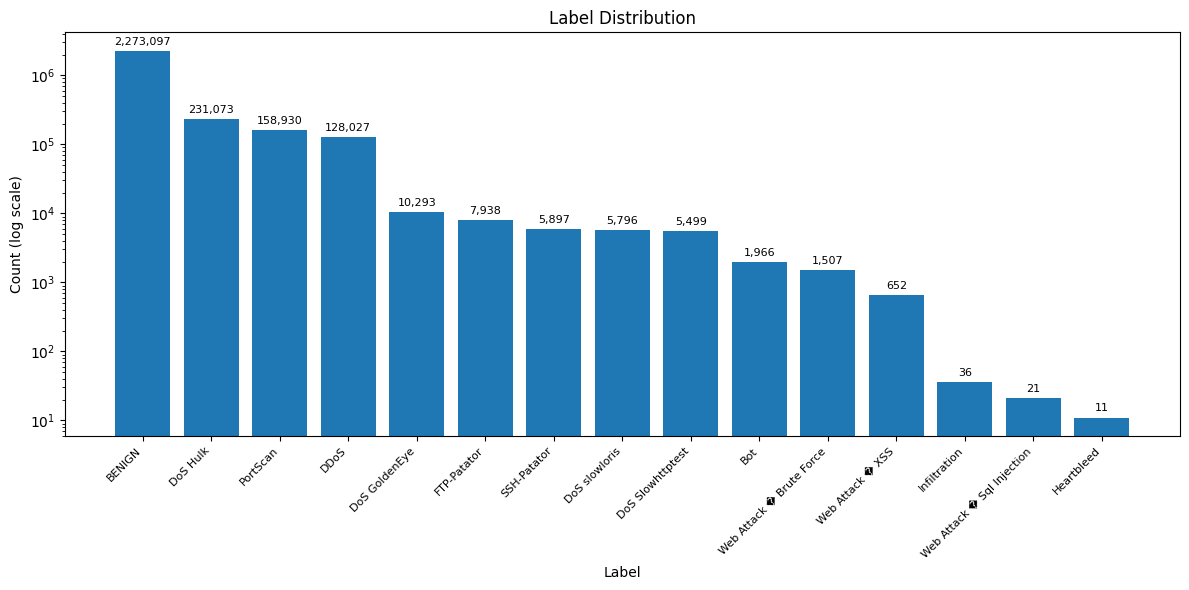

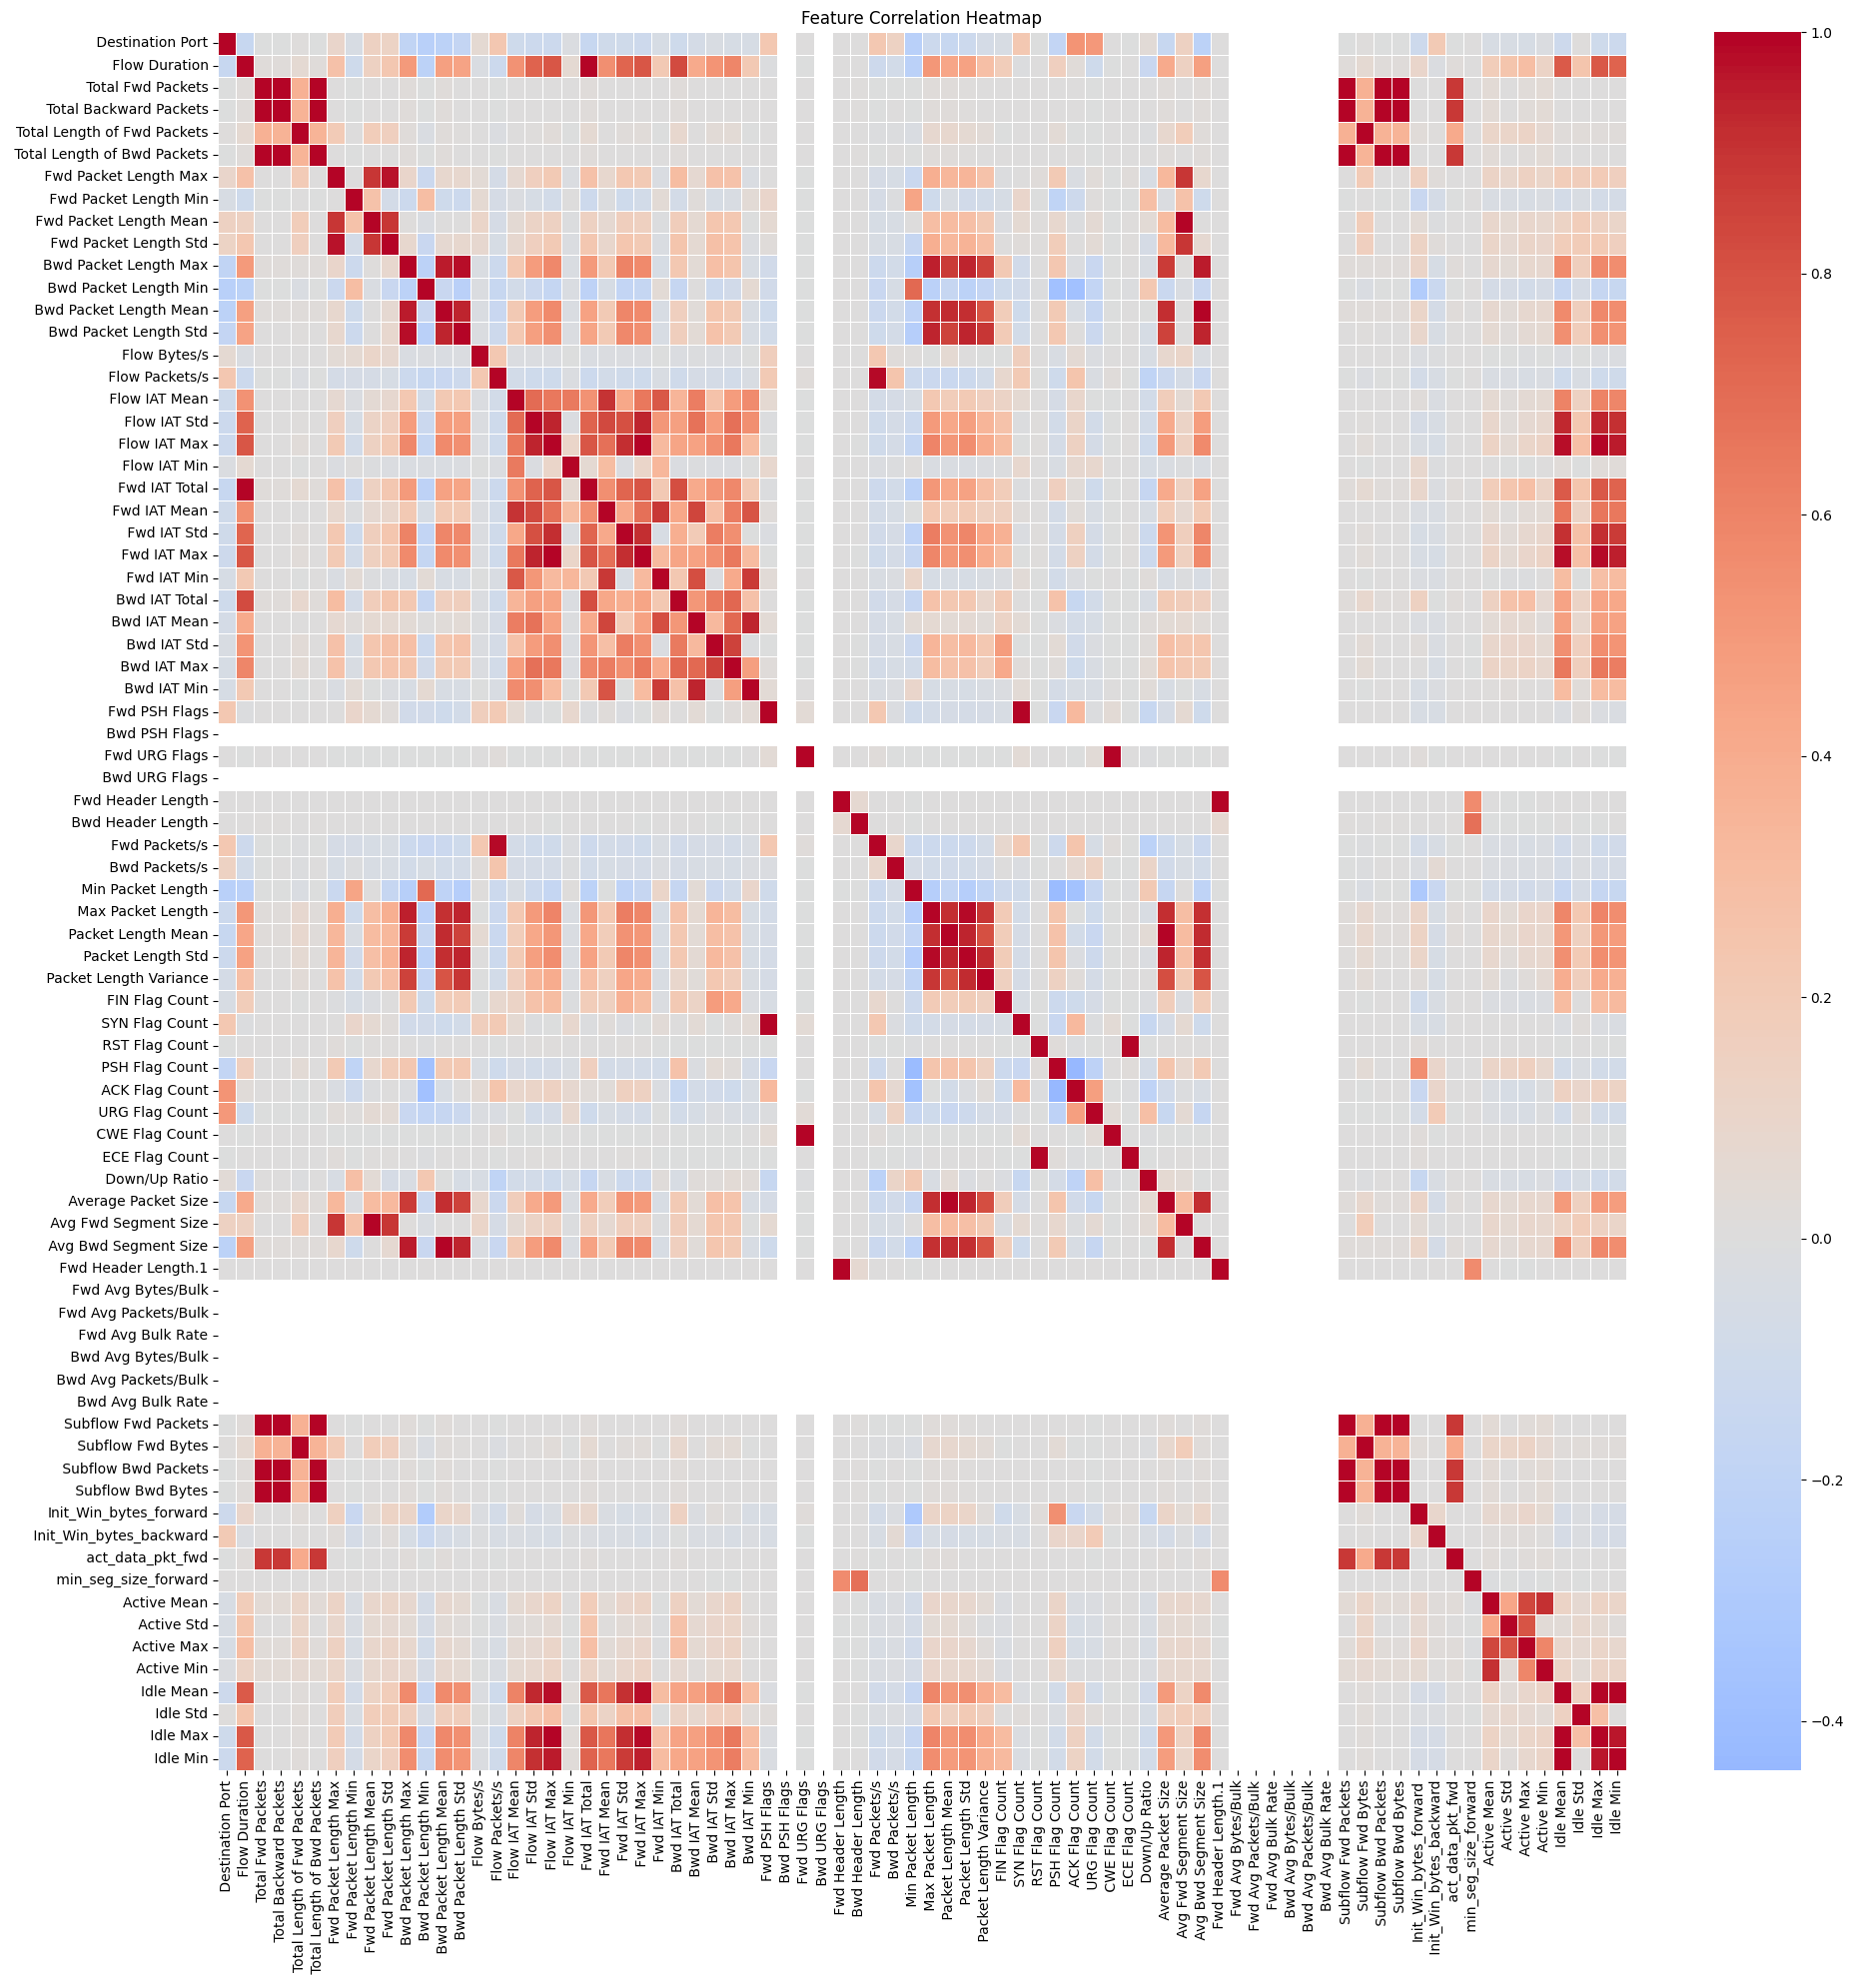

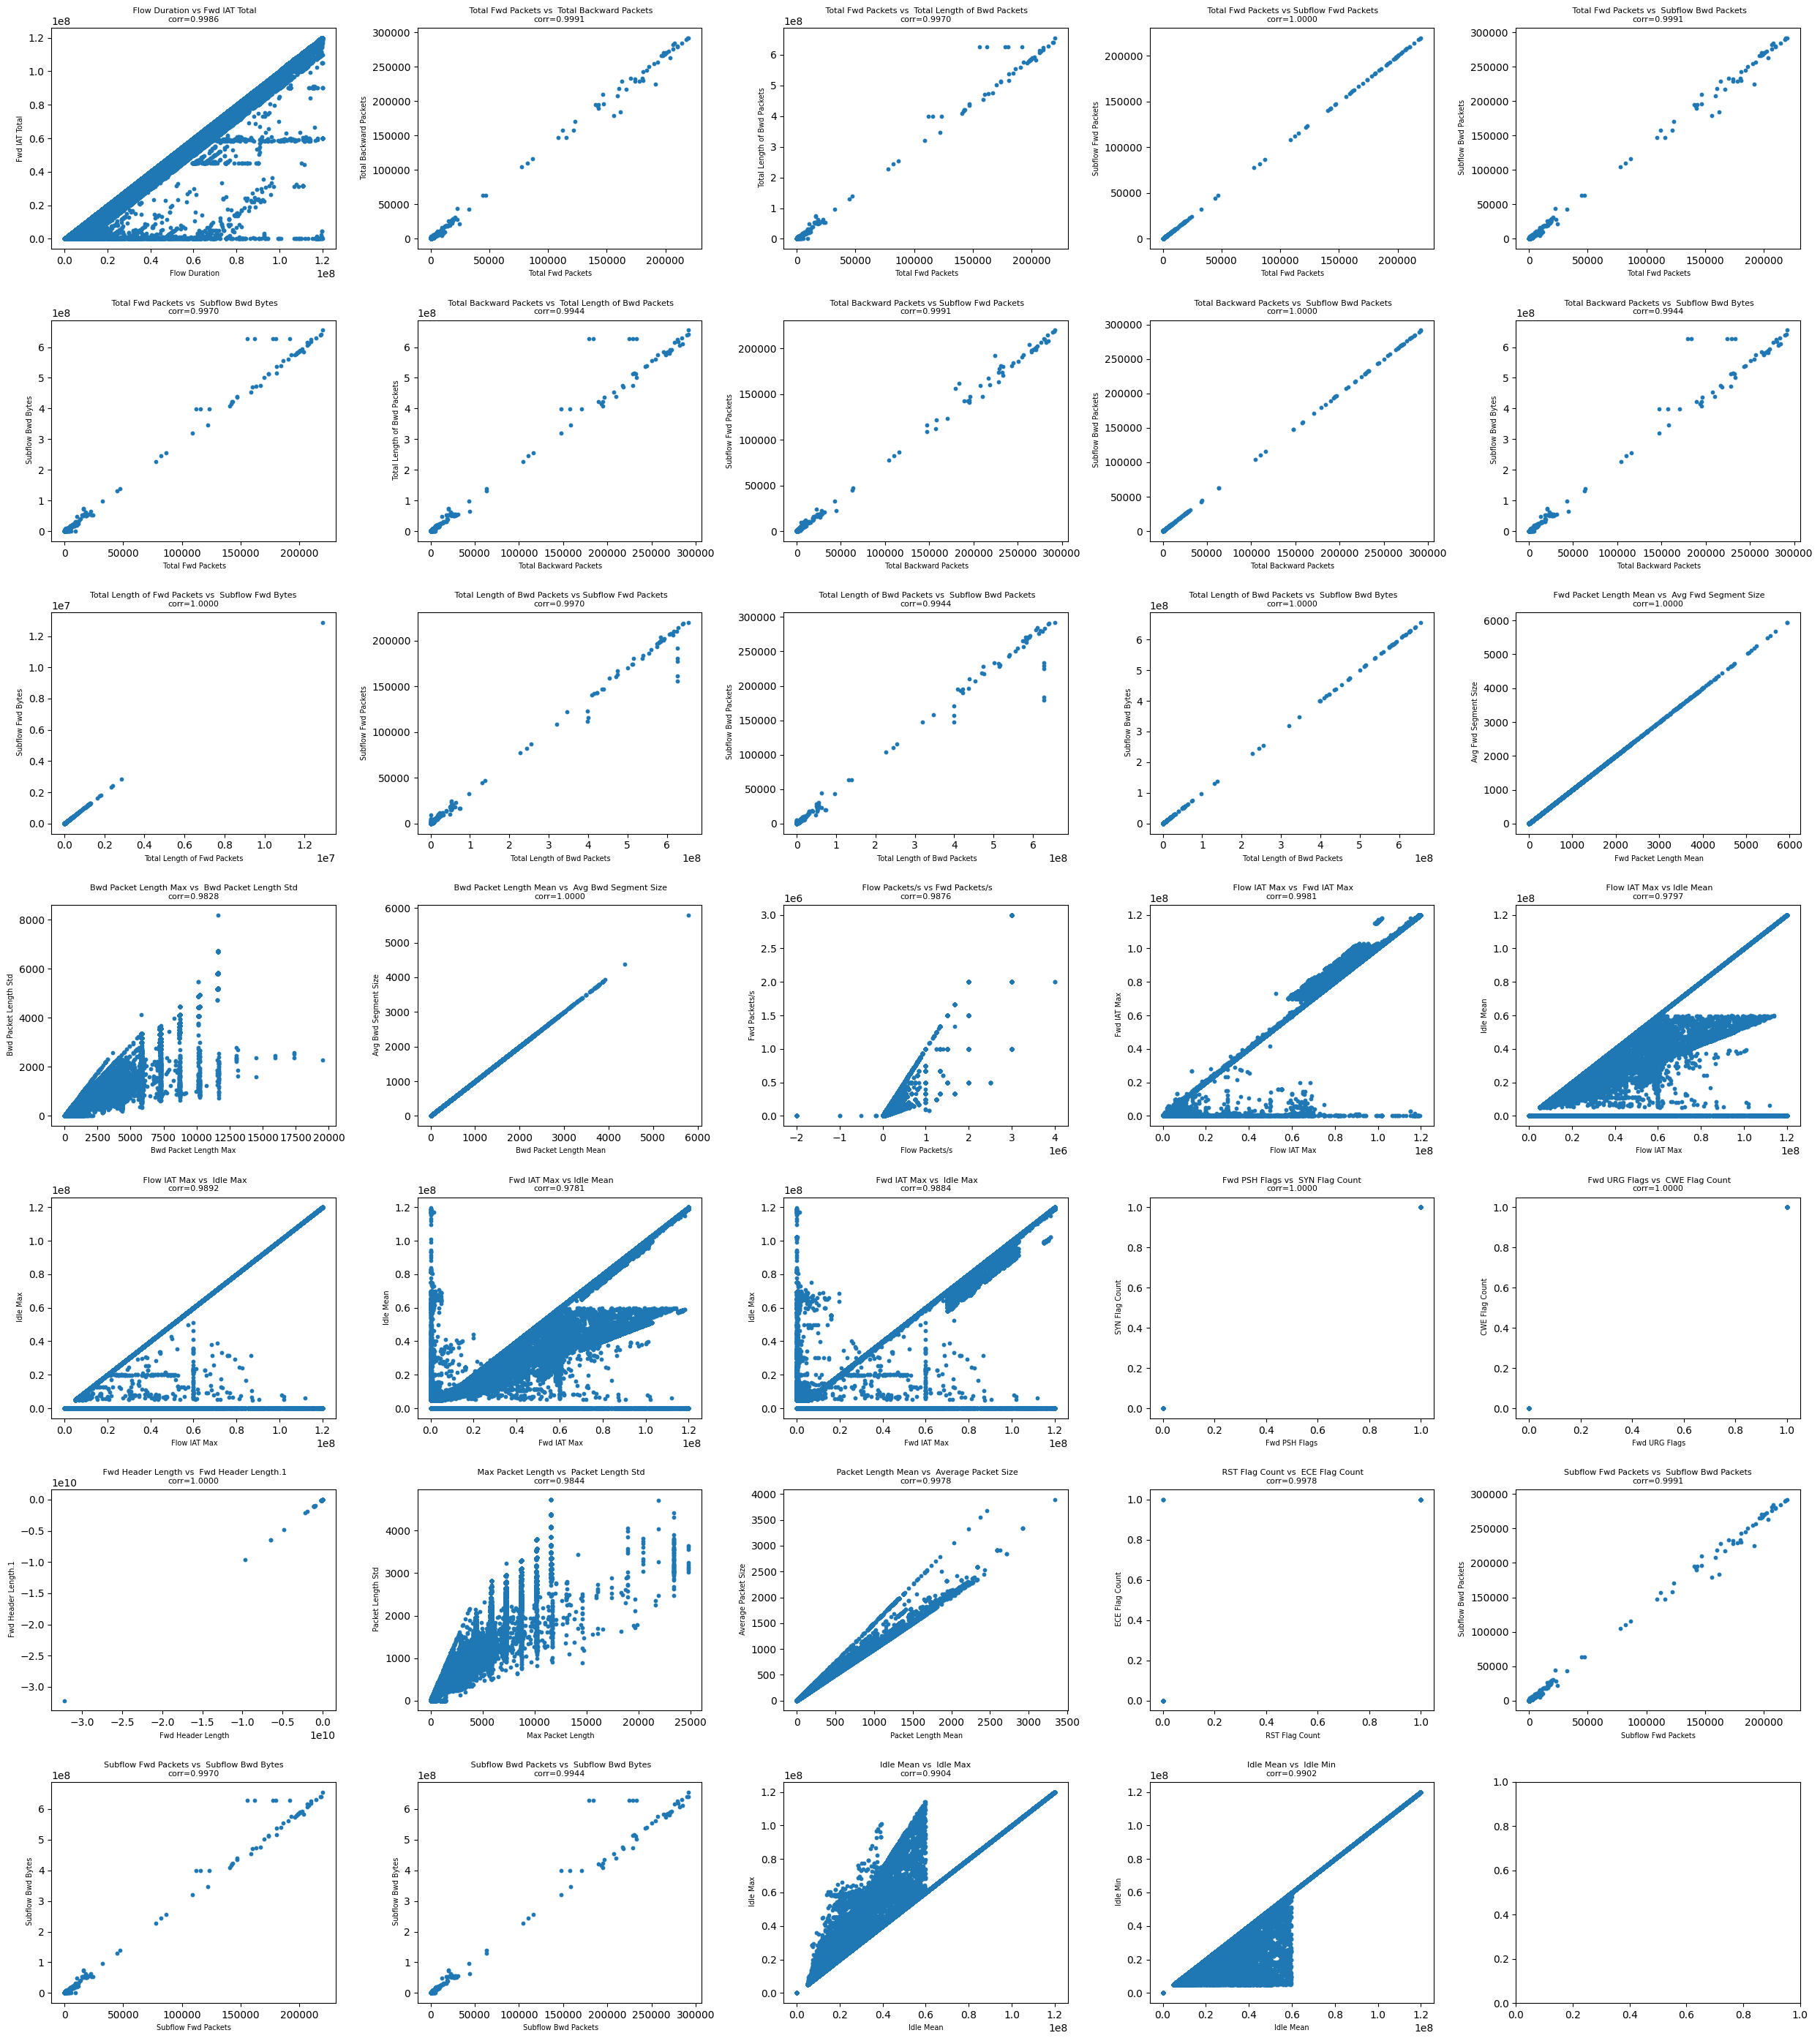

In [3]:
# test visualization
raw_df = load_raw()
plot_label_distribution(raw_df)
plot_correlation_heatmap(raw_df)
plot_correlated_pairs(raw_df, threshold=0.97)

In [3]:
# test resample
from sklearn.model_selection import train_test_split

X = df.drop('Label', axis=1)
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#X_resampled, y_resampled = resample(X_train, y_train)
#print(f"Original class distribution: {y_train.value_counts().to_dict()}")
#print(f"Resampled class distribution: {y_resampled.value_counts().to_dict()}")

In [7]:
weights_by_label = {
      "BENIGN": 1.0,
      "Bot": 0.7,
      "Web Attack - Brute Force": 2.0,
      "Web Attack - XSS": 3.0,
}

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder().fit(y_train)
class_weight = {int(le.transform([k])[0]): float(v) for k, v in weights_by_label.items()}
for i in range(len(le.classes_)):
    class_weight.setdefault(i, 1.0)

X_fit, X_valid, y_fit, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)

artifacts = train_lightgbm_classifier(
    X_fit,
    y_fit,
    X_valid=X_valid,
    y_valid=y_valid,
    class_weight="balanced",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
)

print(lgbm_report(
    artifacts,
    X_test,
    y_test
))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.090852 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12537
[LightGBM] [Info] Number of data points in the train set: 1614311, number of used features: 60
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.70805

KeyboardInterrupt: 

In [7]:

from sklearn.preprocessing import LabelEncoder
X_fit, X_valid, y_fit, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)
weights_by_label = {
    "BENIGN": 1.1428715904420628,
    
    "Bot": 0.3977412236678544,
    #"Web Attack": 2.8624724552290166,
    "Web Attack - XSS": 2.6169318690018715,
}


le = LabelEncoder().fit(y_fit)
class_weight = {
    int(le.transform([label])[0]): float(weight)
    for label, weight in weights_by_label.items()
}
for i in range(len(le.classes_)):
    class_weight.setdefault(i, 1.0)
print(class_weight)


cnn_artifacts = train_cnn_classifier(
    X_fit,
    y_fit,
    X_valid=X_valid,
    y_valid=y_valid,
    class_weight=class_weight,
    epochs=15,
    batch_size=512,
    verbose=1,
    dropout_rate=0,
    dense_units=0,
    conv_filters=[64, 128, 128, 64],
    learning_rate=3e-4,
    kernel_size=3,
)

{0: 1.1428715904420628, 1: 0.3977412236678544, 14: 2.6169318690018715, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0, 8: 1.0, 9: 1.0, 10: 1.0, 11: 1.0, 12: 1.0, 13: 1.0}
Epoch 1/15
3153/3153 ━━━━━━━━━━━━━━━━━━━━ 103s 33ms/step - accuracy: 0.9671 - cross entropy: 0.1213 - loss: 0.1260 - val_accuracy: 0.9790 - val_cross entropy: 0.0528 - val_loss: 0.0528
Epoch 2/15
3153/3153 ━━━━━━━━━━━━━━━━━━━━ 103s 33ms/step - accuracy: 0.9816 - cross entropy: 0.0440 - loss: 0.0452 - val_accuracy: 0.9768 - val_cross entropy: 0.0545 - val_loss: 0.0545
Epoch 3/15
1419/3153 ━━━━━━━━━━━━━━━━━━━━ 53s 31ms/step - accuracy: 0.9830 - cross entropy: 0.0393 - loss: 0.0411

KeyboardInterrupt: 

In [20]:
print(cnn_report(cnn_artifacts, X_test, y_test))

/Users/josephliotta/dev/SCHOOL/machine-learning/cs3540-final/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/josephliotta/dev/SCHOOL/machine-learning/cs3540-final/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

      BENIGN      0.987     0.989     0.988    419297
         Bot      1.000     0.359     0.528       390
        DDoS      0.957     0.998     0.977     25697
         DoS      0.935     0.996     0.964     38656
 FTP-Patator      0.924     0.991     0.956      1187
  Heartbleed      0.000     0.000     0.000         2
Infiltration      0.000     0.000     0.000         7
    PortScan      0.944     0.739     0.829     18164
 SSH-Patator      0.941     0.964     0.952       644
  Web Attack      0.846     0.077     0.141       429

    accuracy                          0.980    504473
   macro avg      0.753     0.611     0.634    504473
weighted avg      0.980     0.980     0.979    504473



/Users/josephliotta/dev/SCHOOL/machine-learning/cs3540-final/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [4]:
X_fit, X_valid, y_fit, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)

mlp_artifacts = train_mlp_classifier(
    X_fit,
    y_fit,
    X_valid=X_valid,
    y_valid=y_valid,
    class_weight="balanced",
    epochs=50,
    batch_size=2048,
    verbose=1,
    dropout_rate=0.15,
)

print(mlp_artifacts.model.evaluate(X_test, y_test))

#print(mlp_report(mlp_artifacts, X_test, y_test))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        15,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,999 (226.56 KB)

 Trainable params: 57,999 (226.56 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50


2026-04-14 12:34:23.787317: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


789/789 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.4898 - loss: 2.4766 - val_accuracy: 0.5576 - val_loss: 3.1925
Epoch 2/50
789/789 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.5109 - loss: 2.1496 - val_accuracy: 0.5729 - val_loss: 4.0137
Epoch 3/50
789/789 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.4950 - loss: 3.1431 - val_accuracy: 0.5635 - val_loss: 6.7376
Epoch 4/50
789/789 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.4295 - loss: 3.0389 - val_accuracy: 0.5710 - val_loss: 8.4517
Epoch 5/50
789/789 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.4203 - loss: 5.5725 - val_accuracy: 0.5214 - val_loss: 17.8160
Epoch 6/50
789/789 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.3793 - loss: 13.1833 - val_accuracy: 0.5639 - val_loss: 41.4482


ValueError: Invalid dtype: str

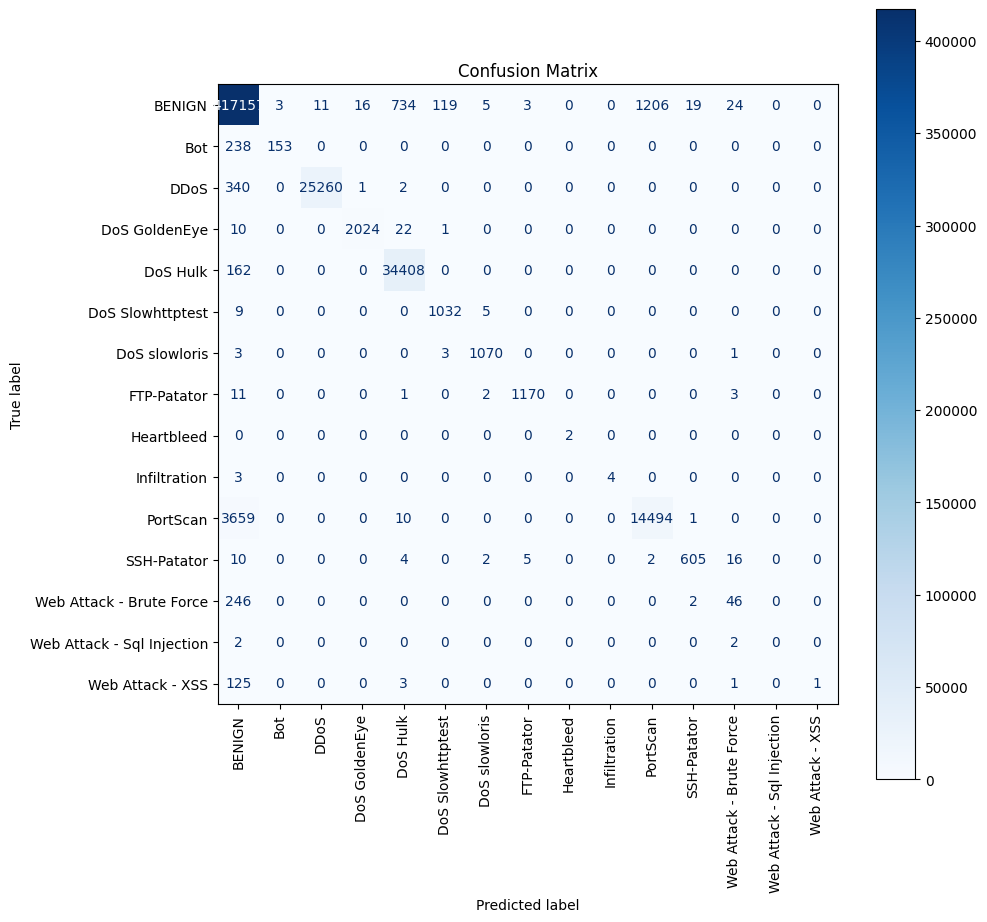

In [10]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
y_pred = predict_labels(cnn_artifacts, X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cnn_artifacts.label_encoder.classes_)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(cmap='Blues', ax=ax, xticks_rotation=90)
plt.title('Confusion Matrix')
plt.show()

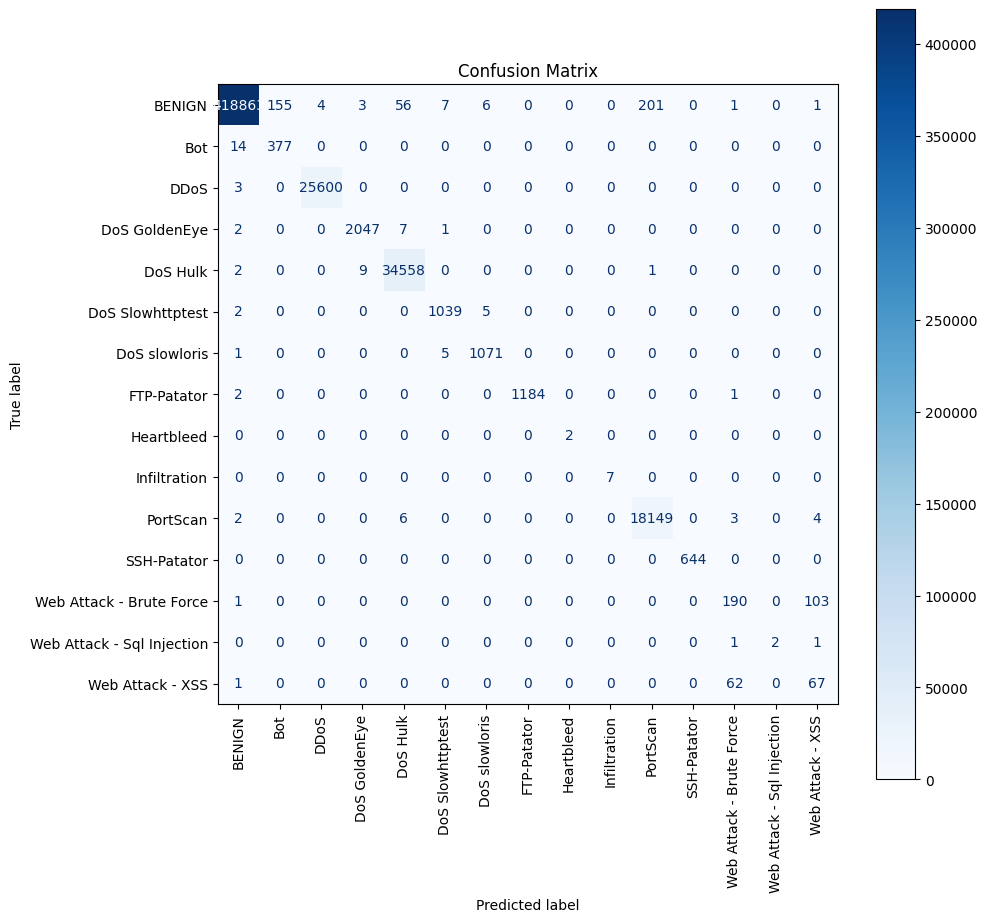

In [14]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
y_pred = lgbm_predict_labels(artifacts, X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=artifacts.label_encoder.classes_)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(cmap='Blues', ax=ax, xticks_rotation=90)
plt.title('Confusion Matrix')
plt.show()